In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load the dataset

df = pd.read_csv('final_cleaned_content_dataset.csv')
df.head()

,content_hash_id,client_hash_id,first_seen,last_seen,active_days,total_impressions,total_clicks,ctr,avg_position,total_pageviews,...,perplexity_sessions,gemini_sessions,copilot_sessions,claude_sessions,meta_sessions,other_ai_sessions,has_search,has_engagement,has_ai,is_active
0,content_1a6296faee432dae,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1,content_dc34c661d63e55a9,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2,content_dcbfbaf912c88c76,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
3,content_44de3cf116b9e3f1,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
4,content_c3283758d93f34fd,client_3ffa76342f366962,2026-06-01,2026-06-30,30,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328450 entries, 0 to 328449
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   content_hash_id       328450 non-null  object 
 1   client_hash_id        328450 non-null  object 
 2   first_seen            328450 non-null  object 
 3   last_seen             328450 non-null  object 
 4   active_days           328450 non-null  int64  
 5   total_impressions     328450 non-null  float64
 6   total_clicks          328450 non-null  float64
 7   ctr                   328450 non-null  float64
 8   avg_position          328450 non-null  float64
 9   total_pageviews       328450 non-null  float64
 10  total_engagement_sec  328450 non-null  float64
 11  engagement_per_view   328450 non-null  float64
 12  total_scrolls         328450 non-null  float64
 13  scrolls_per_view      328450 non-null  float64
 14  total_users           328450 non-null  float64
 15  

## **UNIVARIATE ANALYSIS**


In [5]:
# ============================================================
# CELL 2: UNIVARIATE - NUMERICAL VARIABLES
# ============================================================

print("\n" + "="*50)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("="*50)

# Select numerical columns (excluding identifiers and flags)
numerical_cols = [
    'active_days', 'total_impressions', 'total_clicks', 'ctr', 'avg_position',
    'total_pageviews', 'total_engagement_sec', 'engagement_per_view',
    'total_scrolls', 'scrolls_per_view', 'total_users',
    'organic_sessions', 'direct_sessions', 'social_sessions',
    'ai_sessions', 'referral_sessions'
]

# Filter to existing columns
existing_numerical = [col for col in numerical_cols if col in df.columns]

print("\n📊 Statistical Summary for Numerical Variables:")
print("-"*60)
print(df[existing_numerical].describe())

# Additional statistics
print("\n📊 Additional Statistics (Skewness & Kurtosis):")
print("-"*60)
for col in existing_numerical:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    zero_pct = (df[col] == 0).sum() / len(df) * 100
    print(f"{col:>25}: Skew={skew:>8.2f}, Kurtosis={kurt:>8.2f}, Zero%={zero_pct:>5.1f}%")


UNIVARIATE ANALYSIS - NUMERICAL VARIABLES

📊 Statistical Summary for Numerical Variables:
------------------------------------------------------------
         active_days  total_impressions   total_clicks            ctr  \
count  328450.000000       328450.00000  328450.000000  328450.000000   
mean       28.287057          527.93968       3.078198       0.003953   
std         4.057489         3772.03504     364.572582       0.025449   
min         3.000000            0.00000       0.000000       0.000000   
25%        29.000000            0.00000       0.000000       0.000000   
50%        30.000000            0.00000       0.000000       0.000000   
75%        30.000000           81.00000       0.000000       0.000000   
max        30.000000       615012.00000  152170.000000       1.000000   

        avg_position  total_pageviews  total_engagement_sec  \
count  328450.000000    328450.000000         328450.000000   
mean      185.338219        14.800113             33.604171   
s


UNIVARIATE - DISTRIBUTION PLOTS


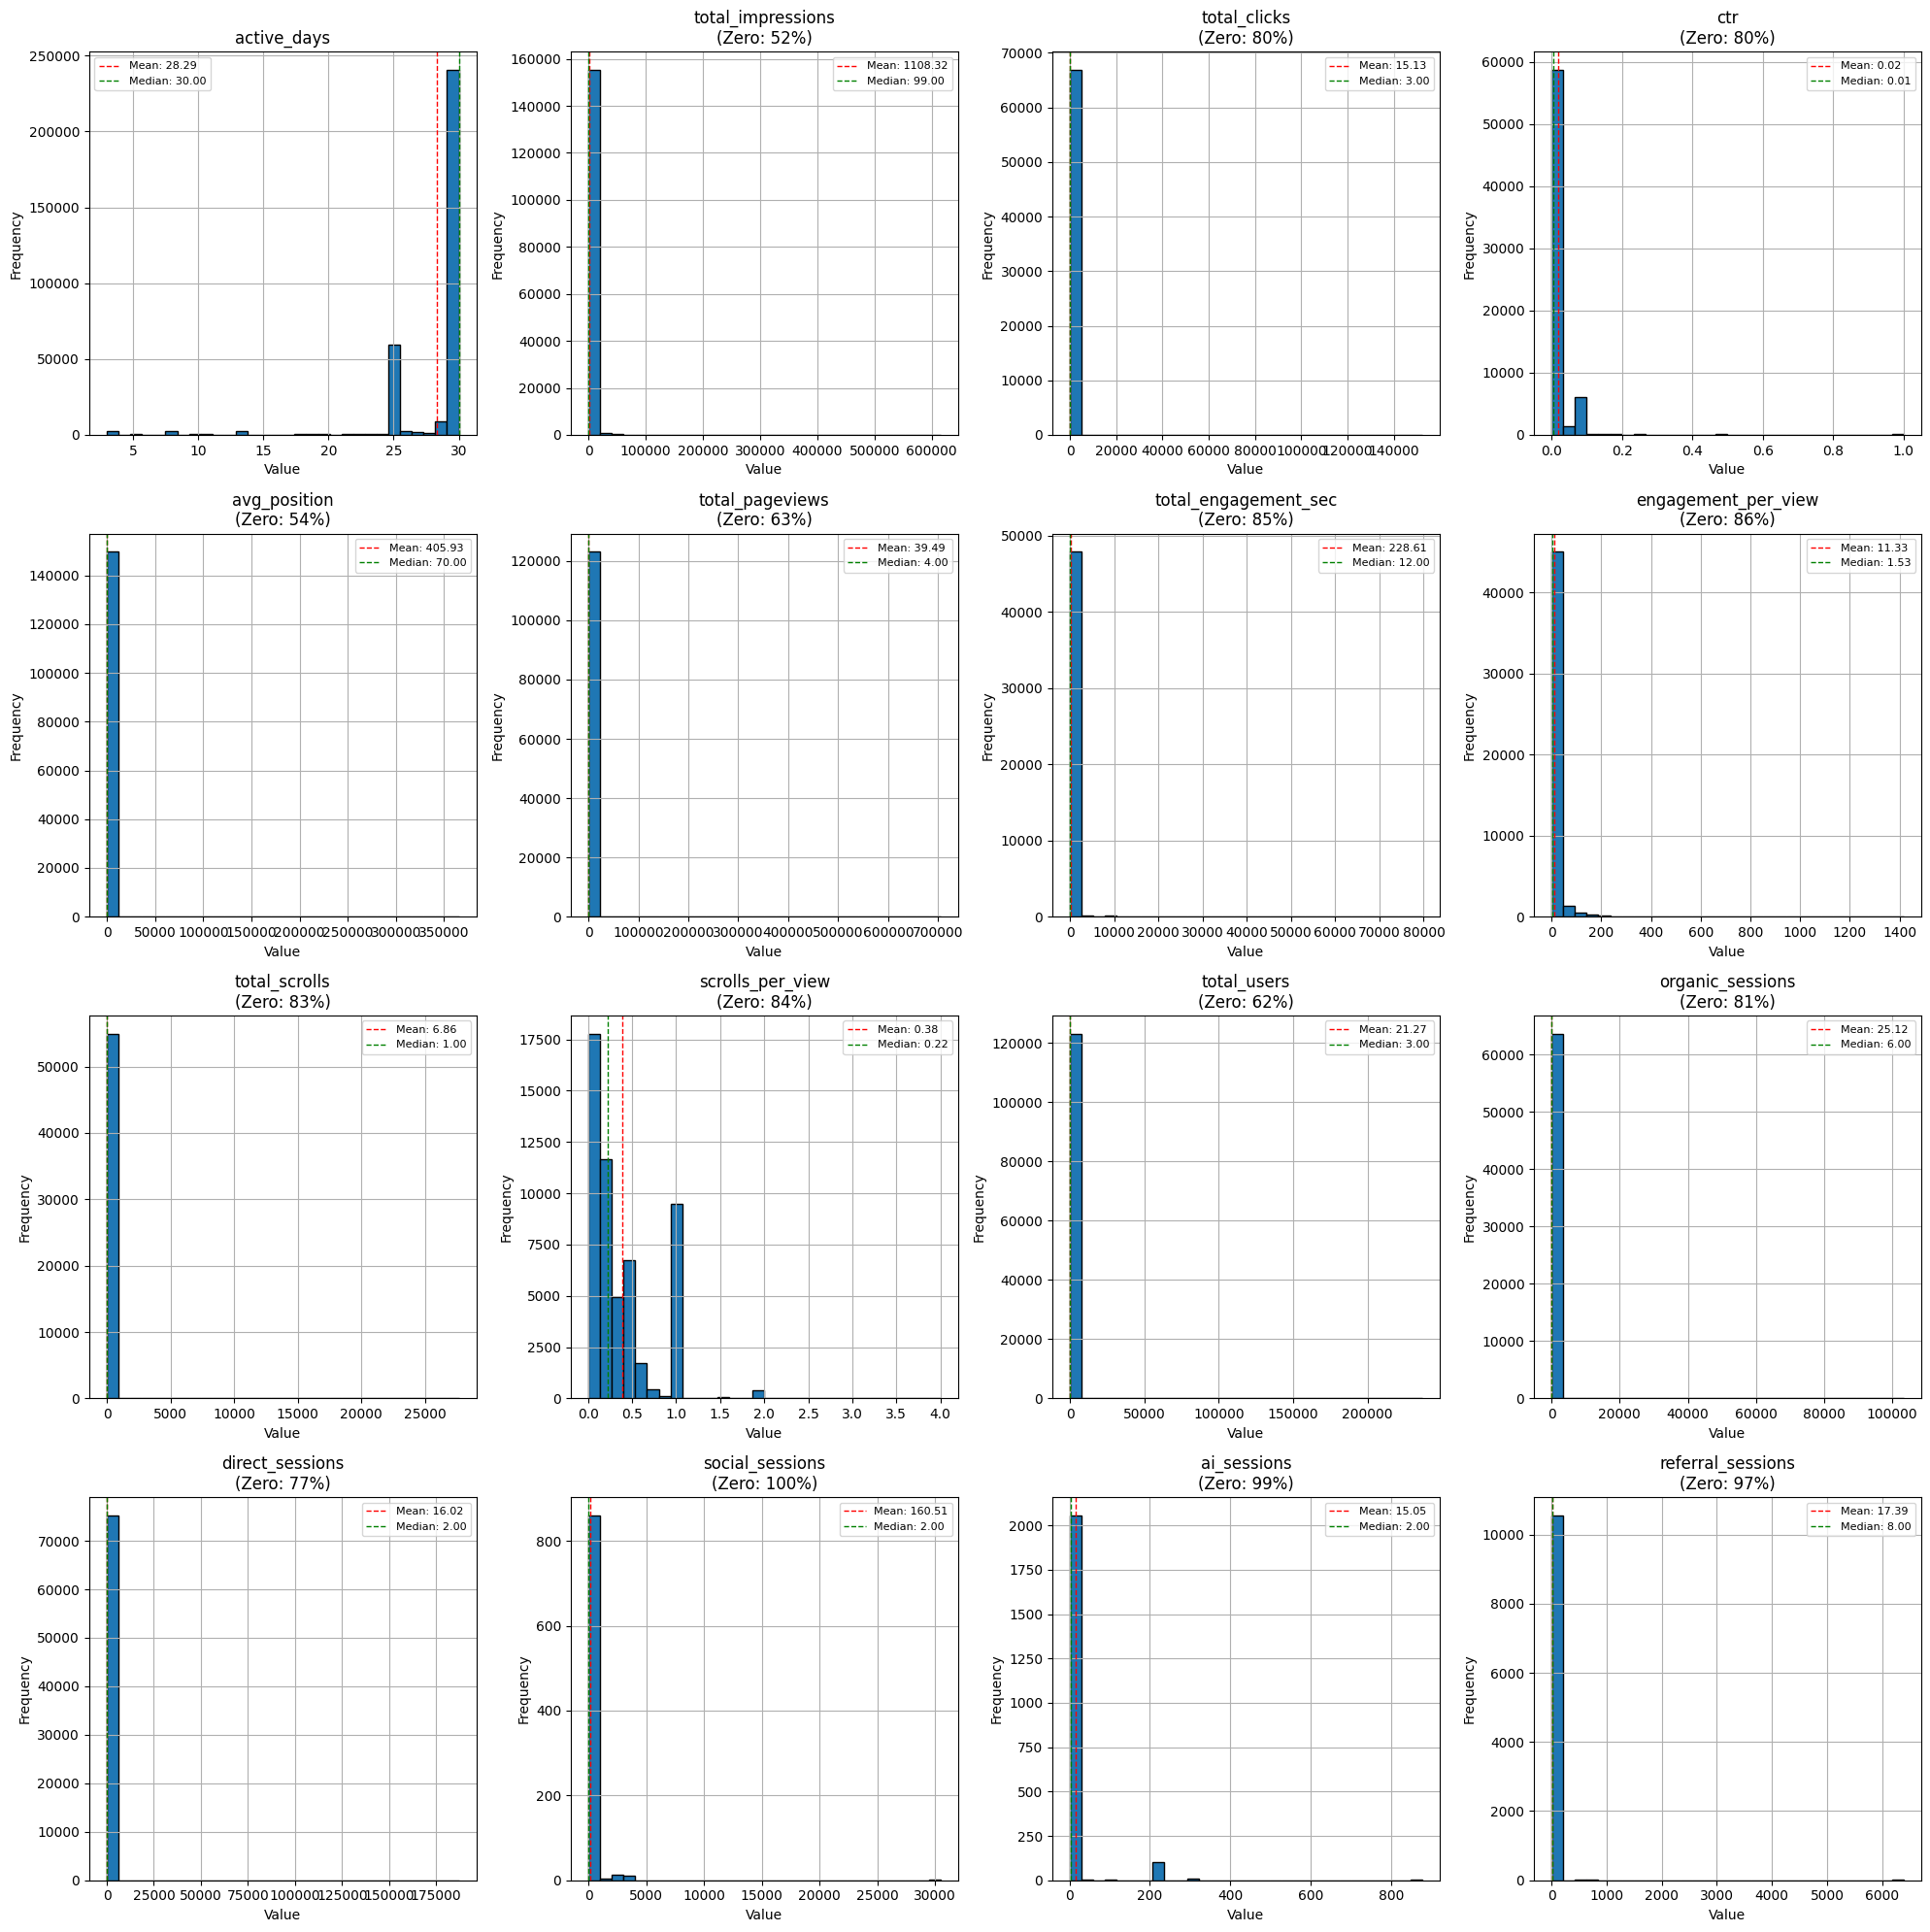

In [7]:
# ============================================================
# CELL 3: UNIVARIATE - DISTRIBUTION PLOTS (HISTOGRAMS)
# ============================================================

print("\n" + "="*50)
print("UNIVARIATE - DISTRIBUTION PLOTS")
print("="*50)

# Create distribution plots for key numerical variables
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, col in enumerate(existing_numerical[:16]):  # Limit to 16 plots
    ax = axes_flat[idx]

    # Filter out zeros for better visualization (for some metrics)
    data = df[col]

    # Check if data has many zeros
    zero_pct = (data == 0).sum() / len(data) * 100
    if zero_pct > 50:
        # Plot only non-zero values
        data = data[data > 0]
        if len(data) > 0:
            data.hist(bins=30, edgecolor='black', ax=ax)
            ax.set_title(f'{col}\n(Zero: {zero_pct:.0f}%)')
    else:
        # Plot all values (log scale if skewed)
        if data.skew() > 1:
            np.log1p(data).hist(bins=30, edgecolor='black', ax=ax)
            ax.set_title(f'{col} (Log Scale)')
        else:
            data.hist(bins=30, edgecolor='black', ax=ax)
            ax.set_title(col)

    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

    # Add mean and median lines
    if len(data) > 0:
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {data.mean():.2f}')
        ax.axvline(data.median(), color='green', linestyle='--', linewidth=1, label=f'Median: {data.median():.2f}')
        ax.legend(fontsize=8)

# Hide any unused subplots
for idx in range(len(existing_numerical), 16):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()


These plots show the distribution of various numerical variables. Many variables like total_impressions, total_clicks, ctr, total_pageviews, total_engagement_sec, total_scrolls, total_users, organic_sessions, direct_sessions, ai_sessions, and referral_sessions exhibit highly skewed distributions, with a large number of zero values. For these, the plots show distributions of non-zero values, often with a log scale to better visualize the shape. active_days appears more normally distributed or uniformly distributed at higher values, likely due to censoring at 30 days.


UNIVARIATE - BOX PLOTS (Outlier Detection)


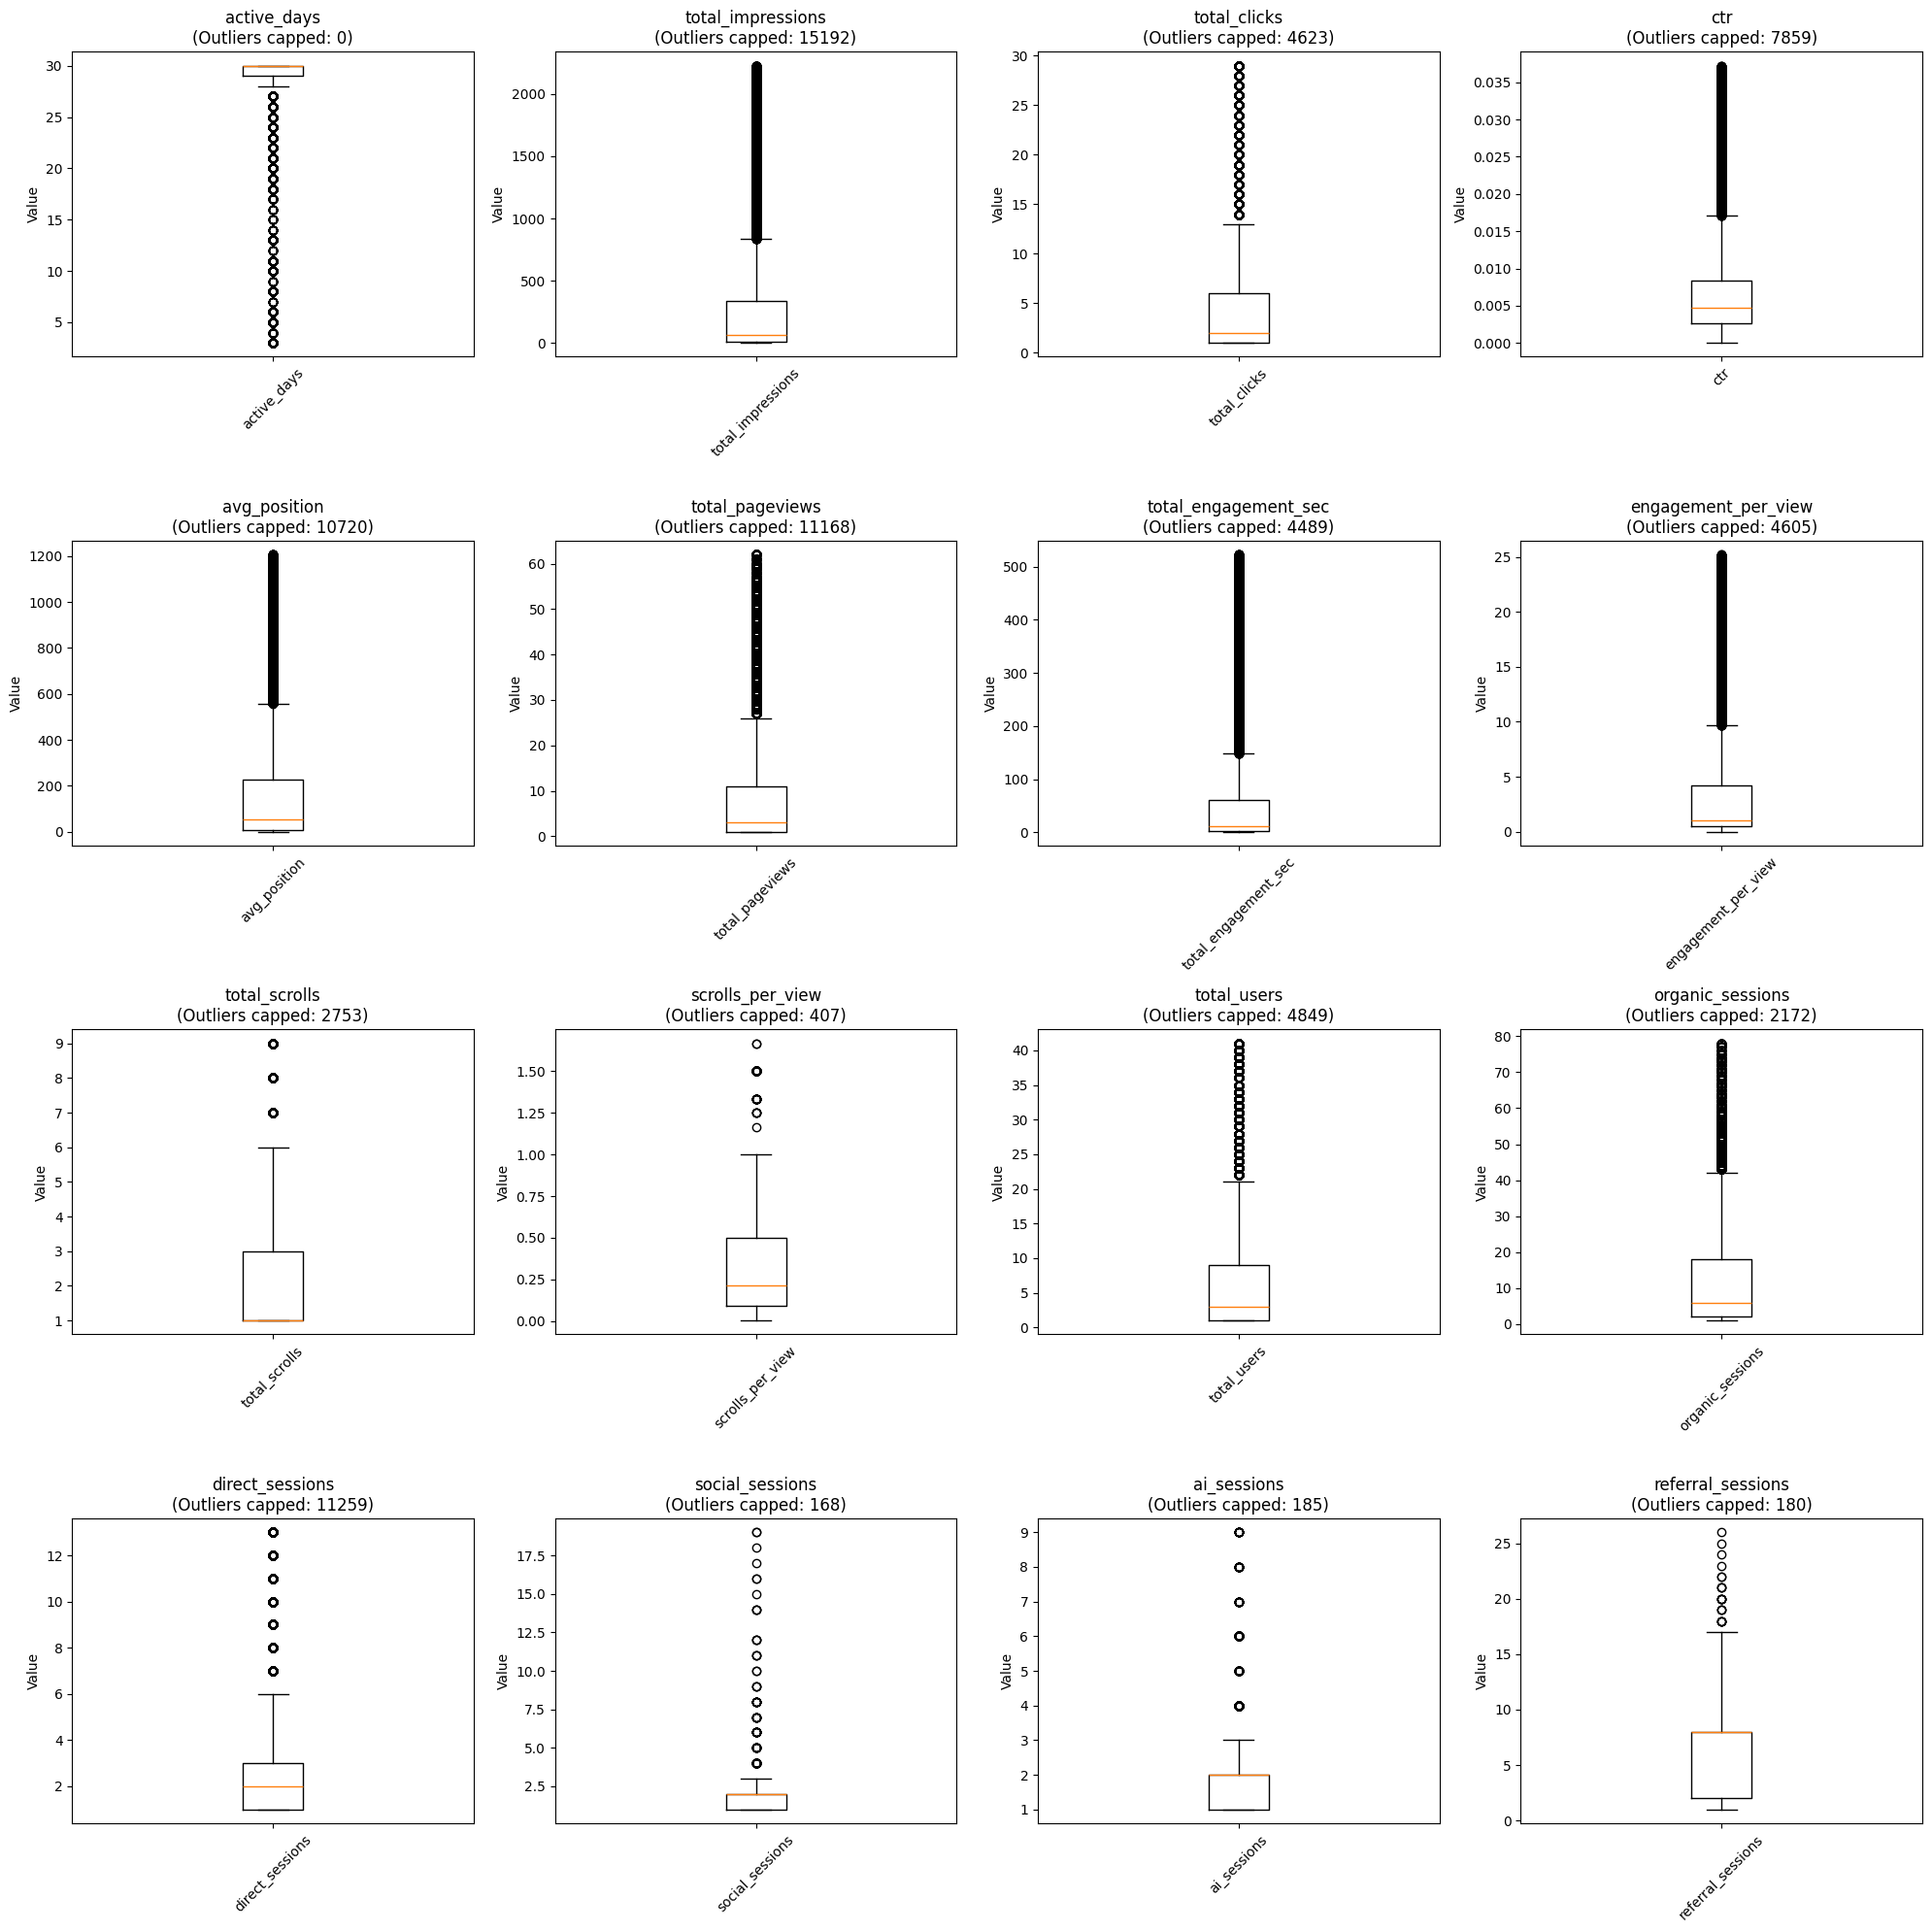

In [8]:
# ============================================================
# CELL 4: UNIVARIATE - BOX PLOTS (OUTLIER DETECTION)
# ============================================================

print("\n" + "="*50)
print("UNIVARIATE - BOX PLOTS (Outlier Detection)")
print("="*50)

# Create box plots for key variables
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes_flat = axes.flatten()

for idx, col in enumerate(existing_numerical[:16]):
    ax = axes_flat[idx]

    # Filter out zeros for better visualization
    data = df[col]
    zero_pct = (data == 0).sum() / len(data) * 100

    if zero_pct > 50:
        data = data[data > 0]

    if len(data) > 0:
        # Cap extreme outliers for visualization
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 3 * IQR
        data_plot = data[data <= upper_bound]

        ax.boxplot(data_plot, vert=True)
        ax.set_title(f'{col}\n(Outliers capped: {len(data) - len(data_plot)})')
        ax.set_ylabel('Value')
        ax.set_xticklabels([col], rotation=45)

# Hide unused subplots
for idx in range(len(existing_numerical), 16):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

These box plots highlight the presence of significant outliers in most numerical features. Due to the extreme skewness and presence of many zeros, the plots often focus on non-zero values and cap extreme outliers for better visualization. This indicates that a small proportion of content pieces drive a disproportionately high amount of activity across metrics like impressions, clicks, pageviews, and sessions.


UNIVARIATE - CATEGORICAL VARIABLES

📊 Categorical Variable Distributions:
------------------------------------------------------------

has_search:
has_search
0    171996
1    156454
Name: count, dtype: int64
  Percentage:
has_search
0    52.365961
1    47.634039
Name: proportion, dtype: float64

has_engagement:
has_engagement
0    205341
1    123109
Name: count, dtype: int64
  Percentage:
has_engagement
0    62.518192
1    37.481808
Name: proportion, dtype: float64

has_ai:
has_ai
0    326273
1      2177
Name: count, dtype: int64
  Percentage:
has_ai
0    99.33719
1     0.66281
Name: proportion, dtype: float64

is_active:
is_active
1    175233
0    153217
Name: count, dtype: int64
  Percentage:
is_active
1    53.351499
0    46.648501
Name: proportion, dtype: float64


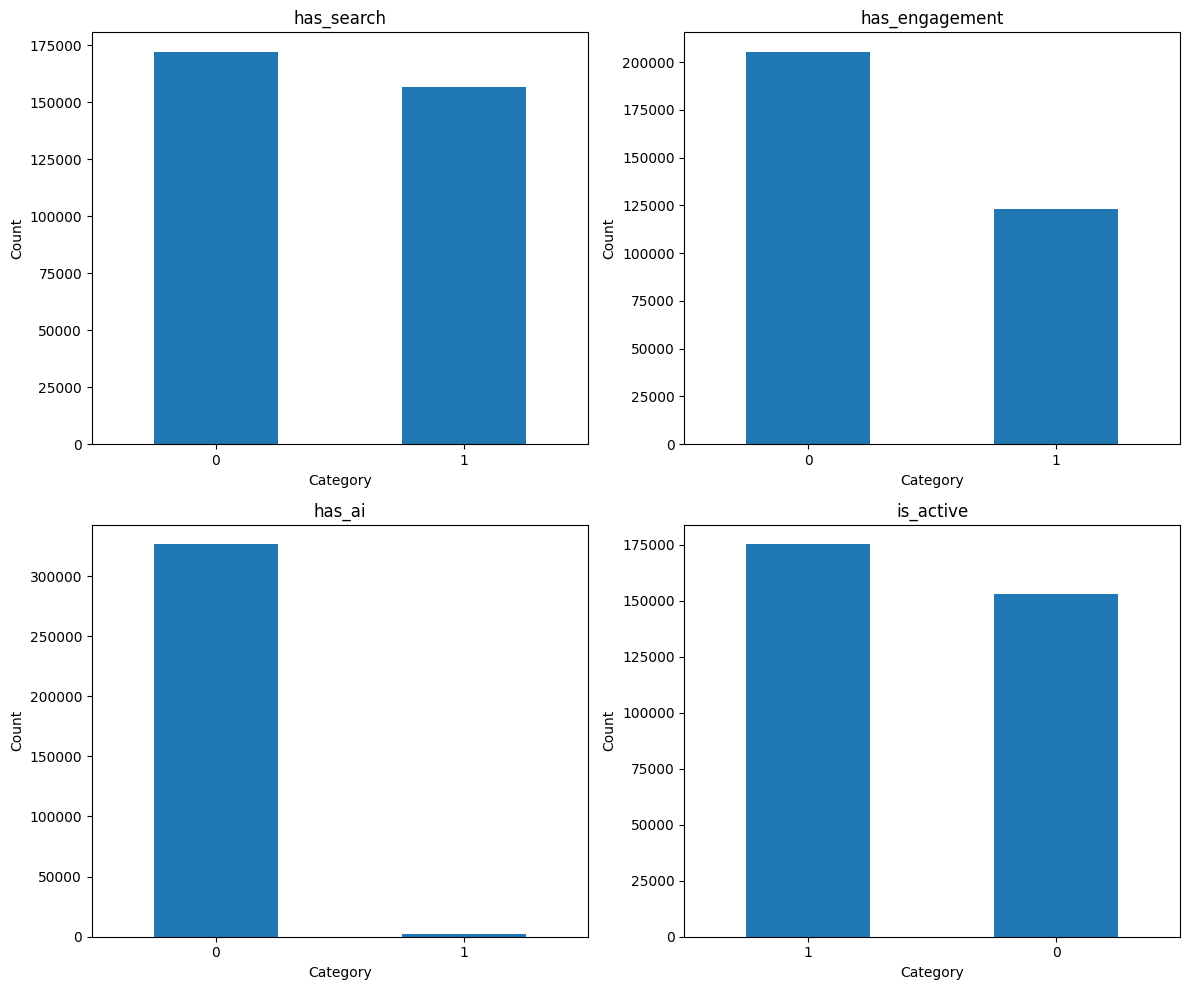

In [9]:
# ============================================================
# CELL 5: UNIVARIATE - CATEGORICAL VARIABLES
# ============================================================

print("\n" + "="*50)
print("UNIVARIATE - CATEGORICAL VARIABLES")
print("="*50)

# Identify categorical/flag columns
categorical_cols = ['has_search', 'has_engagement', 'has_ai', 'is_active']

print("\n📊 Categorical Variable Distributions:")
print("-"*60)

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"  Percentage:")
        print(df[col].value_counts(normalize=True) * 100)

# Visualize categorical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, col in enumerate(categorical_cols):
    if col in df.columns:
        ax = axes[idx // 2, idx % 2]
        df[col].value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f'{col}')
        ax.set_xlabel('Category')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

- has_search: Roughly half of the content (47.6%) has associated search activity.

- has_engagement: A substantial portion (37.5%) of the content records engagement.

- has_ai: Only a very small percentage (0.7%) of the content has AI-driven traffic, suggesting this is a niche but potentially growing channel.

- is_active: Over half (53.4%) of the content pieces are considered active





## **BI-VARIATE ANALYSIS**



PART 2: BIVARIATE ANALYSIS

Analyzing relationships between two variables.

BIVARIATE - CORRELATION ANALYSIS

📊 Correlations with Target Variables:
------------------------------------------------------------

CTR:
           organic_sessions:    0.064
                total_users:    0.059
            direct_sessions:    0.058
              total_scrolls:    0.057
            total_pageviews:    0.057

TOTAL_IMPRESSIONS:
               avg_position:    0.664
       total_engagement_sec:    0.260
           organic_sessions:    0.247
               total_clicks:    0.219
              total_scrolls:    0.212

TOTAL_PAGEVIEWS:
            direct_sessions:    0.999
           organic_sessions:    0.992
               total_clicks:    0.989
                total_users:    0.986
            social_sessions:    0.980

AI_SESSIONS:
              total_scrolls:    0.650
                total_users:    0.602
           organic_sessions:    0.592
          referral_sessions:    0.559
          

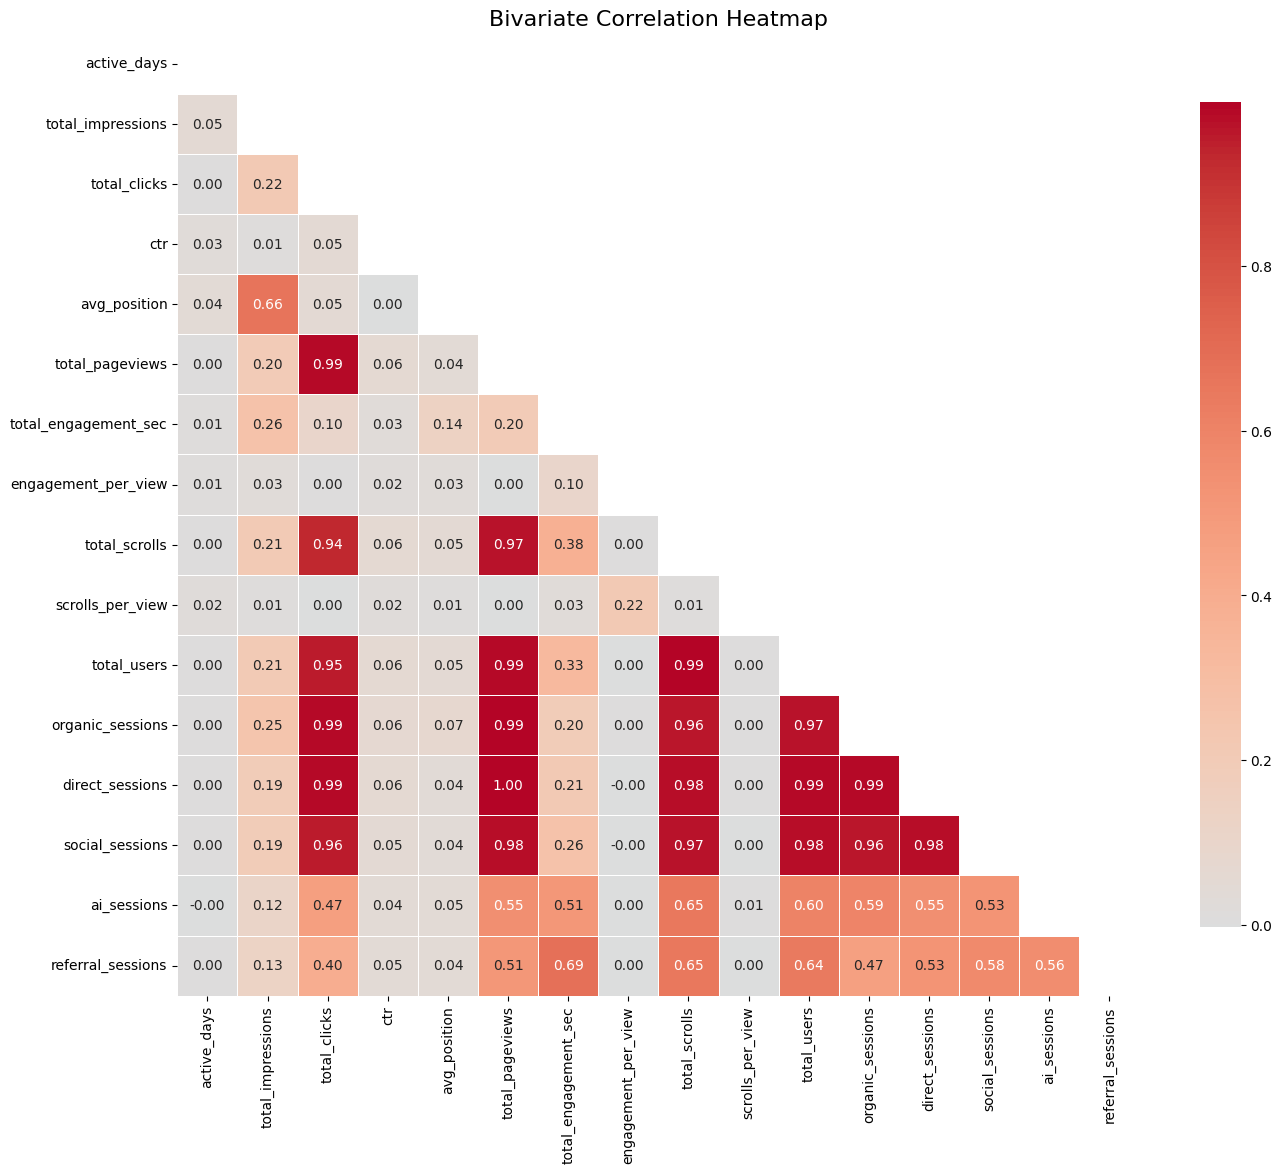

In [10]:
# ============================================================
# PART 2: BIVARIATE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("PART 2: BIVARIATE ANALYSIS")
print("="*70)
print("\nAnalyzing relationships between two variables.")

# ============================================================
# CELL 6: BIVARIATE - CORRELATION ANALYSIS
# ============================================================

print("\n" + "="*50)
print("BIVARIATE - CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
corr_matrix = df[existing_numerical].corr()

# Display correlations with key target variables
target_vars = ['ctr', 'total_impressions', 'total_pageviews', 'ai_sessions']

print("\n📊 Correlations with Target Variables:")
print("-"*60)

for target in target_vars:
    if target in corr_matrix.columns:
        print(f"\n{target.upper()}:")
        correlations = corr_matrix[target].sort_values(ascending=False)
        for var, corr in correlations.drop(target).head(5).items():
            print(f"  {var:>25}: {corr:>8.3f}")

# Create correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Bivariate Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

The heatmap shows the correlation between numerical variables. Key observations include:

- Strong positive correlations exist between various session metrics (total_pageviews, organic_sessions, direct_sessions, total_clicks, total_users, total_scrolls). This suggests that content performing well in one engagement metric tends to perform well across others.

- avg_position has a notable positive correlation with total_impressions, which might seem counter-intuitive as lower average position (higher rank) usually means more impressions. This could indicate that content with higher average position (lower rank) might be receiving more impressions, but in absolute terms might be low-quality impressions, which require further investigation. Or, more likely, it could indicate that avg_position refers to the numerical value of position (higher number = lower rank), and therefore higher avg_position (lower rank) correlates with higher impressions, possibly due to a very large number of impressions at lower positions, although this would need more context.

- ctr (Click-Through Rate) generally shows low correlations with other variables, suggesting it's influenced by a more complex interplay of factors not solely captured by raw volume metrics.
ai_sessions shows moderate positive correlations with total_scrolls, total_users, and organic_sessions, indicating that content driving AI sessions also tends to perform well in other engagement areas.


BIVARIATE - SCATTER PLOTS


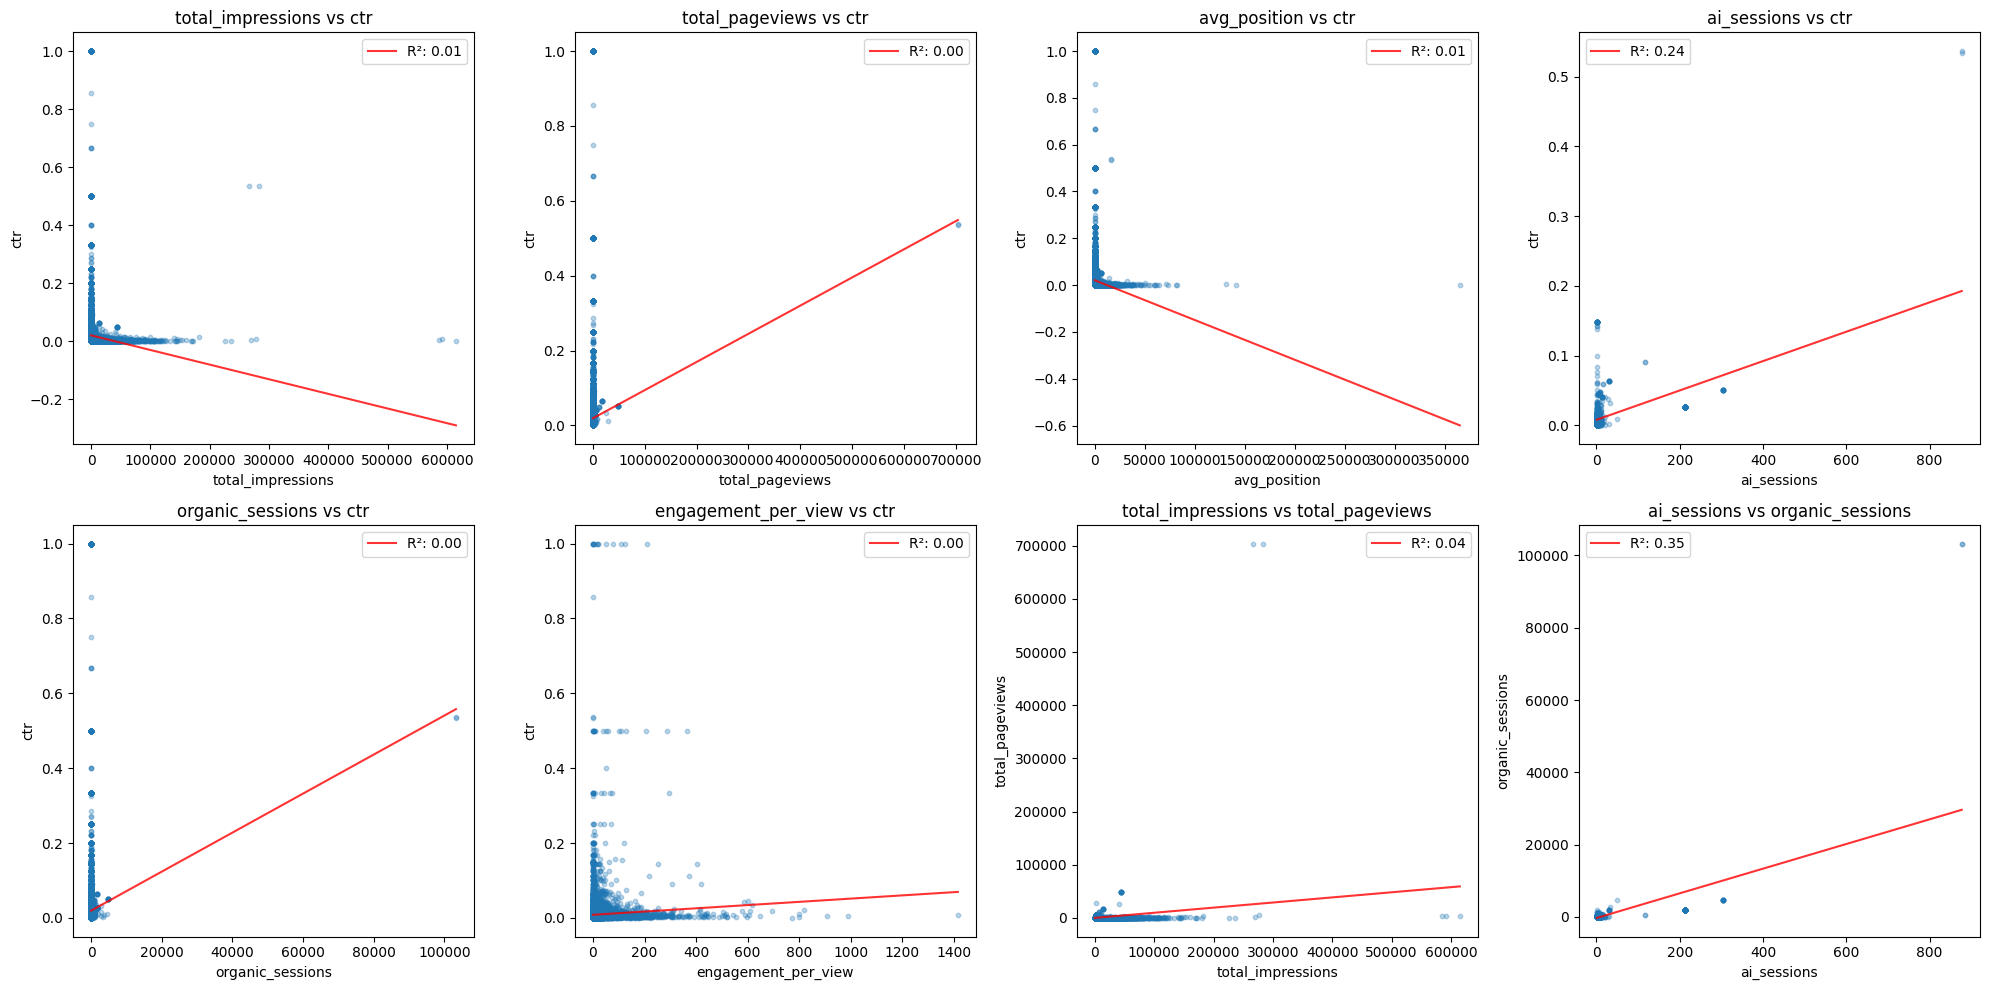

In [11]:
# ============================================================
# CELL 7: BIVARIATE - SCATTER PLOTS (KEY RELATIONSHIPS)
# ============================================================

print("\n" + "="*50)
print("BIVARIATE - SCATTER PLOTS")
print("="*50)

# Define key relationships to explore
relationships = [
    ('total_impressions', 'ctr'),
    ('total_pageviews', 'ctr'),
    ('avg_position', 'ctr'),
    ('ai_sessions', 'ctr'),
    ('organic_sessions', 'ctr'),
    ('engagement_per_view', 'ctr'),
    ('total_impressions', 'total_pageviews'),
    ('ai_sessions', 'organic_sessions')
]

# Create scatter plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for idx, (x_var, y_var) in enumerate(relationships):
    if x_var in df.columns and y_var in df.columns:
        ax = axes_flat[idx]

        # Filter out zeros for better visualization
        data = df[(df[x_var] > 0) & (df[y_var] > 0)]

        if len(data) > 0:
            ax.scatter(data[x_var], data[y_var], alpha=0.3, s=10)
            ax.set_xlabel(x_var)
            ax.set_ylabel(y_var)
            ax.set_title(f'{x_var} vs {y_var}')

            # Add trend line
            z = np.polyfit(data[x_var], data[y_var], 1)
            p = np.poly1d(z)
            ax.plot(data[x_var].sort_values(), p(data[x_var].sort_values()),
                   "r-", alpha=0.8, label=f'R²: {np.corrcoef(data[x_var], data[y_var])[0,1]**2:.2f}')
            ax.legend()

# Hide unused subplots
for idx in range(len(relationships), 8):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

These scatter plots visualize relationships between selected pairs of variables, filtering out zero values for clarity. Many plots show a positive, though often scattered, relationship, particularly between volume metrics (e.g., total_impressions vs total_pageviews). The R² values (squared correlation coefficient) on the trend lines indicate the strength of linear relationships, which are generally low to moderate, suggesting non-linearities or other influencing factors.




BIVARIATE - BOX PLOTS BY CATEGORY


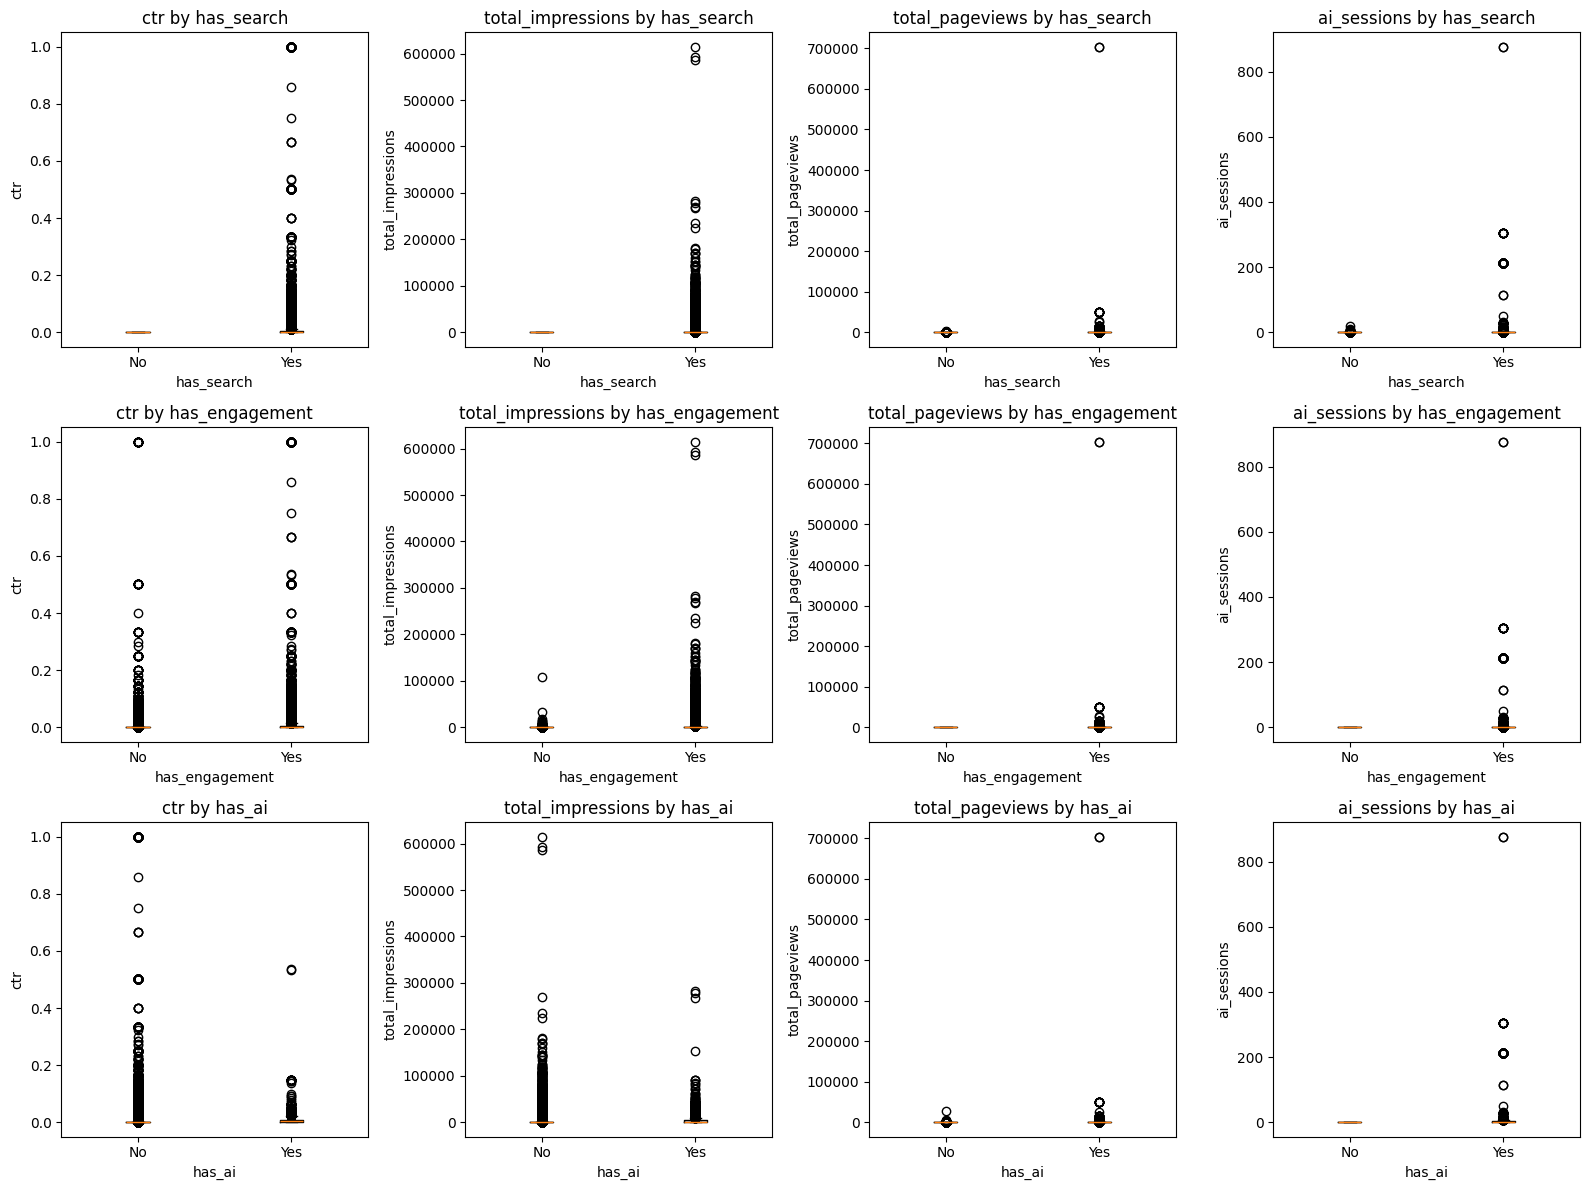

In [12]:
# ============================================================
# CELL 8: BIVARIATE - BOX PLOTS BY CATEGORY
# ============================================================

print("\n" + "="*50)
print("BIVARIATE - BOX PLOTS BY CATEGORY")
print("="*50)

# Compare metrics across categories
categorical_cols = ['has_search', 'has_engagement', 'has_ai']
metrics_to_compare = ['ctr', 'total_impressions', 'total_pageviews', 'ai_sessions']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, cat_col in enumerate(categorical_cols):
    if cat_col in df.columns:
        for col, metric in enumerate(metrics_to_compare):
            if metric in df.columns:
                ax = axes[row, col]

                # Create box plots
                data_to_plot = [df[df[cat_col] == 0][metric], df[df[cat_col] == 1][metric]]
                ax.boxplot(data_to_plot, labels=['No', 'Yes'])
                ax.set_title(f'{metric} by {cat_col}')
                ax.set_ylabel(metric)
                ax.set_xlabel(cat_col)

plt.tight_layout()
plt.show()

These plots compare key performance metrics (ctr, total_impressions, total_pageviews, ai_sessions) across content grouped by categorical flags (has_search, has_engagement, has_ai).

- has_search: Content with search activity (has_search = 1) tends to have higher ctr, total_impressions, and total_pageviews compared to content without search activity. This highlights the importance of search visibility.
- has_engagement: Content with engagement (has_engagement = 1) generally shows higher values for all compared metrics, as expected, confirming that engagement is a strong indicator of overall content performance.
- has_ai: Content with AI sessions (has_ai = 1) exhibits significantly higher ai_sessions, ctr, total_impressions, and total_pageviews. This confirms that the small percentage of content interacting with AI channels is highly impactful.


BIVARIATE - AI CHANNEL ANALYSIS

📊 AI Channel Distribution:
--------------------------------------------------
        chatgpt:       29,113 ( 88.8%)
     perplexity:        1,101 (  3.4%)
         gemini:        1,495 (  4.6%)
        copilot:          665 (  2.0%)
         claude:          402 (  1.2%)
           meta:            0 (  0.0%)
       other_ai:            0 (  0.0%)


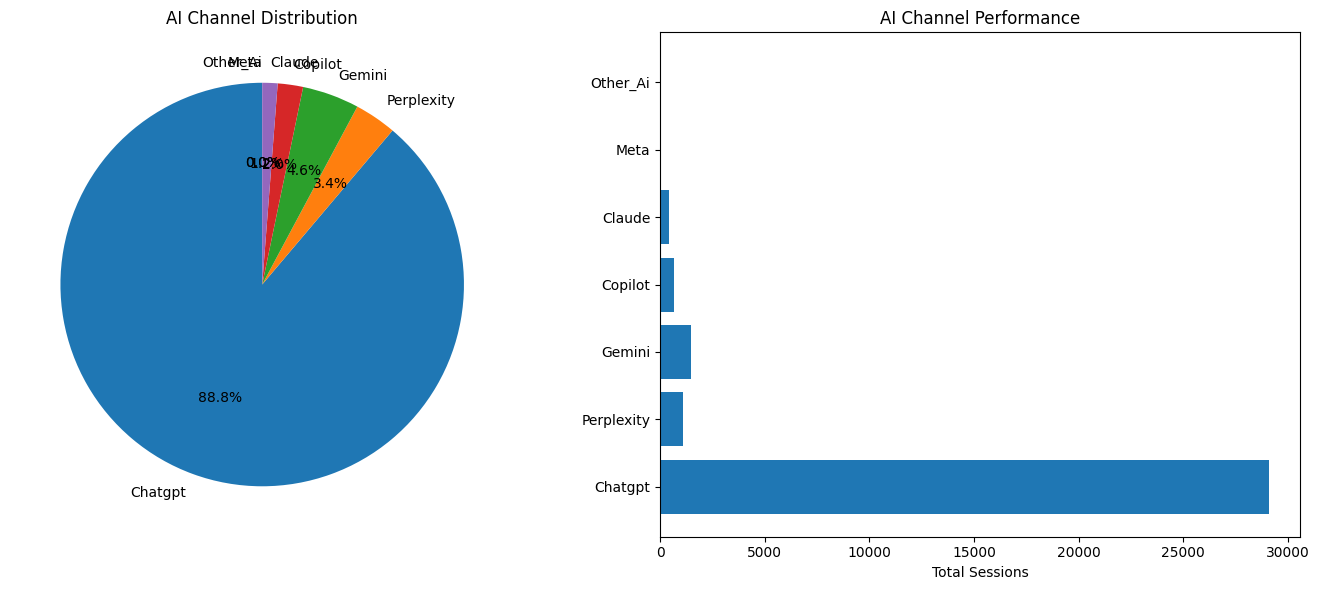

In [17]:
# ============================================================
# CELL 9: BIVARIATE - AI CHANNEL ANALYSIS
# ============================================================

print("\n" + "="*50)
print("BIVARIATE - AI CHANNEL ANALYSIS")
print("="*50)

# AI channel breakdown
ai_channels = ['chatgpt_sessions', 'perplexity_sessions', 'gemini_sessions',
               'copilot_sessions', 'claude_sessions', 'meta_sessions', 'other_ai_sessions']

# Filter to existing channels
existing_ai = [col for col in ai_channels if col in df.columns]

if existing_ai:
    # Calculate totals
    ai_totals = df[existing_ai].sum()

    print("\n📊 AI Channel Distribution:")
    print("-"*50)
    for channel in existing_ai:
        channel_name = channel.replace('_sessions', '')
        total = ai_totals[channel]
        pct = total / ai_totals.sum() * 100
        print(f"{channel_name:>15}: {total:>12,.0f} ({pct:>5.1f}%)")

    # Visualize AI channels
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Pie chart
    axes[0].pie(ai_totals.values,
                labels=[c.replace('_sessions', '').title() for c in ai_totals.index],
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('AI Channel Distribution')

    # Bar chart
    axes[1].barh([c.replace('_sessions', '').title() for c in ai_totals.index],
                 ai_totals.values)
    axes[1].set_xlabel('Total Sessions')
    axes[1].set_title('AI Channel Performance')

    plt.tight_layout()
    plt.show()

AI Channel Distribution:

- ChatGPT is by far the dominant AI channel, accounting for about 88.8% of all AI sessions.

- Gemini and Perplexity contribute smaller but significant shares (4.6% and 3.4% respectively), while

- Copilot and Claude are less prominent. Meta and other AI channels have negligible activity.

AI Channel Performance:

The bar chart visually reinforces the dominance of ChatGPT in terms of total sessions.

## **MULTI-VARIATE ANALYSIS**


PART 3: MULTIVARIATE ANALYSIS

Analyzing relationships between multiple variables simultaneously.

MULTIVARIATE - COMPREHENSIVE CORRELATION MATRIX


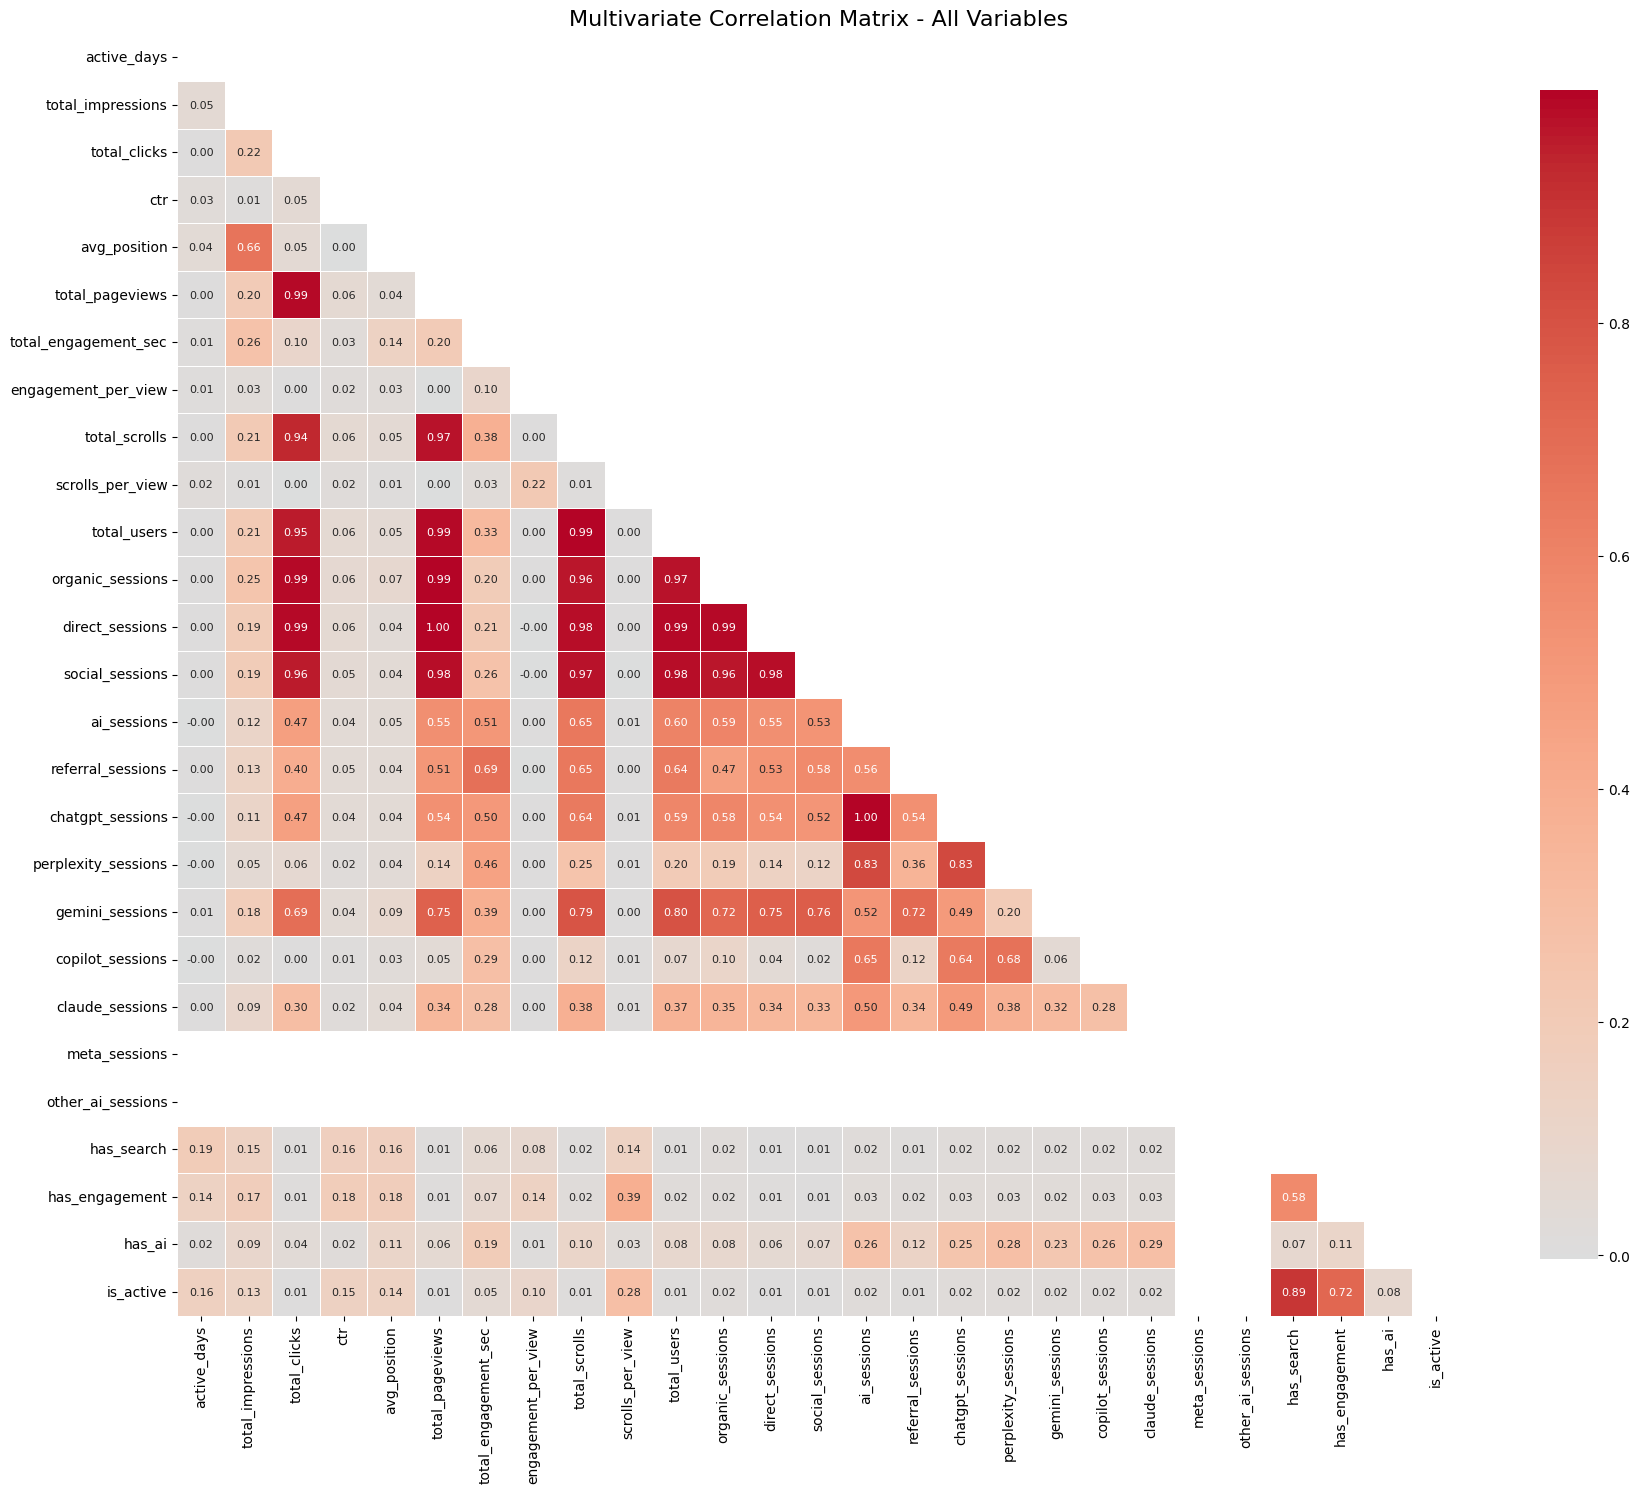

In [18]:
# ============================================================
# PART 3: MULTIVARIATE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("PART 3: MULTIVARIATE ANALYSIS")
print("="*70)
print("\nAnalyzing relationships between multiple variables simultaneously.")

# ============================================================
# CELL 10: MULTIVARIATE - COMPREHENSIVE CORRELATION MATRIX
# ============================================================

print("\n" + "="*50)
print("MULTIVARIATE - COMPREHENSIVE CORRELATION MATRIX")
print("="*50)

# Create comprehensive correlation matrix with all variables
all_numeric = df.select_dtypes(include=[np.number]).columns
full_corr = df[all_numeric].corr()

# Create larger heatmap
plt.figure(figsize=(18, 16))
mask = np.triu(np.ones_like(full_corr, dtype=bool))
sns.heatmap(full_corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title('Multivariate Correlation Matrix - All Variables', fontsize=16)
plt.tight_layout()
plt.show()

This larger heatmap confirms the patterns observed in the bivariate correlation matrix, showing the full inter-correlations among all numerical variables. It highlights clusters of highly correlated variables, especially within impression/click/session metrics, and further emphasizes the generally weaker correlations involving ctr.


MULTIVARIATE - PRINCIPAL COMPONENT ANALYSIS (PCA)

📊 Explained Variance by Components:
--------------------------------------------------
PC1: 44.98% (Cumulative: 44.98%)
PC2: 16.54% (Cumulative: 61.52%)
PC3: 11.53% (Cumulative: 73.05%)
PC4: 9.93% (Cumulative: 82.99%)
PC5: 9.76% (Cumulative: 92.75%)


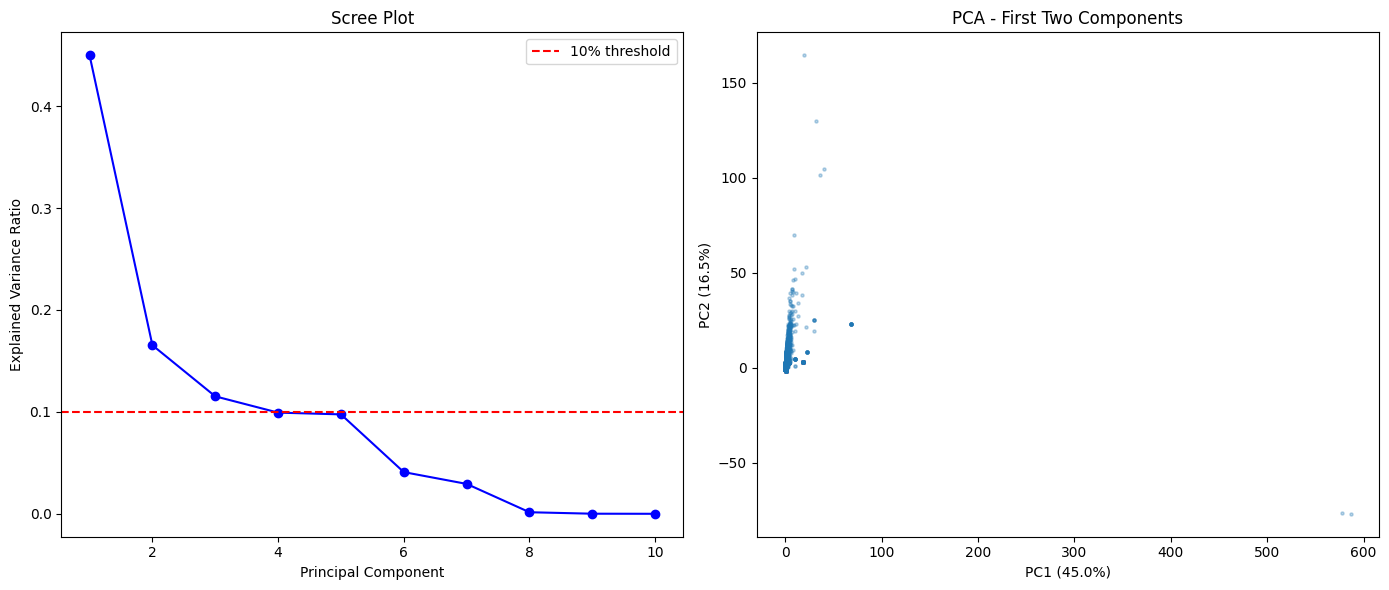


📊 Feature Loadings on PC1 and PC2:
--------------------------------------------------
                           PC1       PC2
total_impressions     0.151061  0.646555
total_clicks          0.443512 -0.128554
ctr                   0.033676 -0.056177
avg_position          0.067712  0.673371
total_pageviews       0.456809 -0.123193
total_engagement_sec  0.176991  0.271638
engagement_per_view   0.005949  0.069537
total_scrolls         0.463724 -0.077877
organic_sessions      0.460612 -0.094376
ai_sessions           0.327903  0.009181


In [19]:
# ============================================================
# CELL 11: MULTIVARIATE - PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================================

print("\n" + "="*50)
print("MULTIVARIATE - PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*50)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data for PCA
pca_columns = [
    'total_impressions', 'total_clicks', 'ctr', 'avg_position',
    'total_pageviews', 'total_engagement_sec', 'engagement_per_view',
    'total_scrolls', 'organic_sessions', 'ai_sessions'
]

existing_pca = [col for col in pca_columns if col in df.columns]

# Filter out rows with all zeros
pca_data = df[existing_pca].copy()
pca_data = pca_data[(pca_data > 0).any(axis=1)]

if len(pca_data) > 0:
    # Standardize data
    scaler = StandardScaler()
    pca_scaled = scaler.fit_transform(pca_data)

    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(pca_scaled)

    # Explained variance
    explained_variance = pca.explained_variance_ratio_

    print("\n📊 Explained Variance by Components:")
    print("-"*50)
    for i, var in enumerate(explained_variance[:5], 1):
        print(f"PC{i}: {var*100:.2f}% (Cumulative: {explained_variance[:i].sum()*100:.2f}%)")

    # Create PCA visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scree plot
    axes[0].plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('Scree Plot')
    axes[0].axhline(y=0.1, color='r', linestyle='--', label='10% threshold')
    axes[0].legend()

    # First two components scatter plot
    axes[1].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=5)
    axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
    axes[1].set_title('PCA - First Two Components')

    plt.tight_layout()
    plt.show()

    # Feature loadings on first two components
    loadings = pd.DataFrame(
        pca.components_[:2].T,
        columns=['PC1', 'PC2'],
        index=existing_pca
    )
    print("\n📊 Feature Loadings on PC1 and PC2:")
    print("-"*50)
    print(loadings)

- Scree Plot: The scree plot shows that the first principal component (PC1) explains about 45% of the variance, and the second (PC2) explains an additional 16.5%. Together, the first two components capture over 60% of the total variance, and the first five components capture nearly 93%, suggesting that a significant portion of the data's complexity can be represented in a lower-dimensional space.
- PCA - First Two Components Plot: The scatter plot of the first two principal components shows the data points spread out, with some clusters or density variations. This visualization helps in understanding the overall structure and potential groupings within the data based on the selected performance metrics.
- Feature Loadings on PC1 and PC2:
  - PC1 is strongly associated with volume metrics like total_clicks, total_pageviews, total_scrolls, organic_sessions, and ai_sessions. This suggests PC1 primarily captures the overall activity or 'volume' of content interaction.
  - PC2 is largely driven by total_impressions and avg_position. This component seems to represent a mix of visibility and possibly ranking impact.


MULTIVARIATE - PAIRPLOT (Selected Variables)


<Figure size 1400x1200 with 0 Axes>

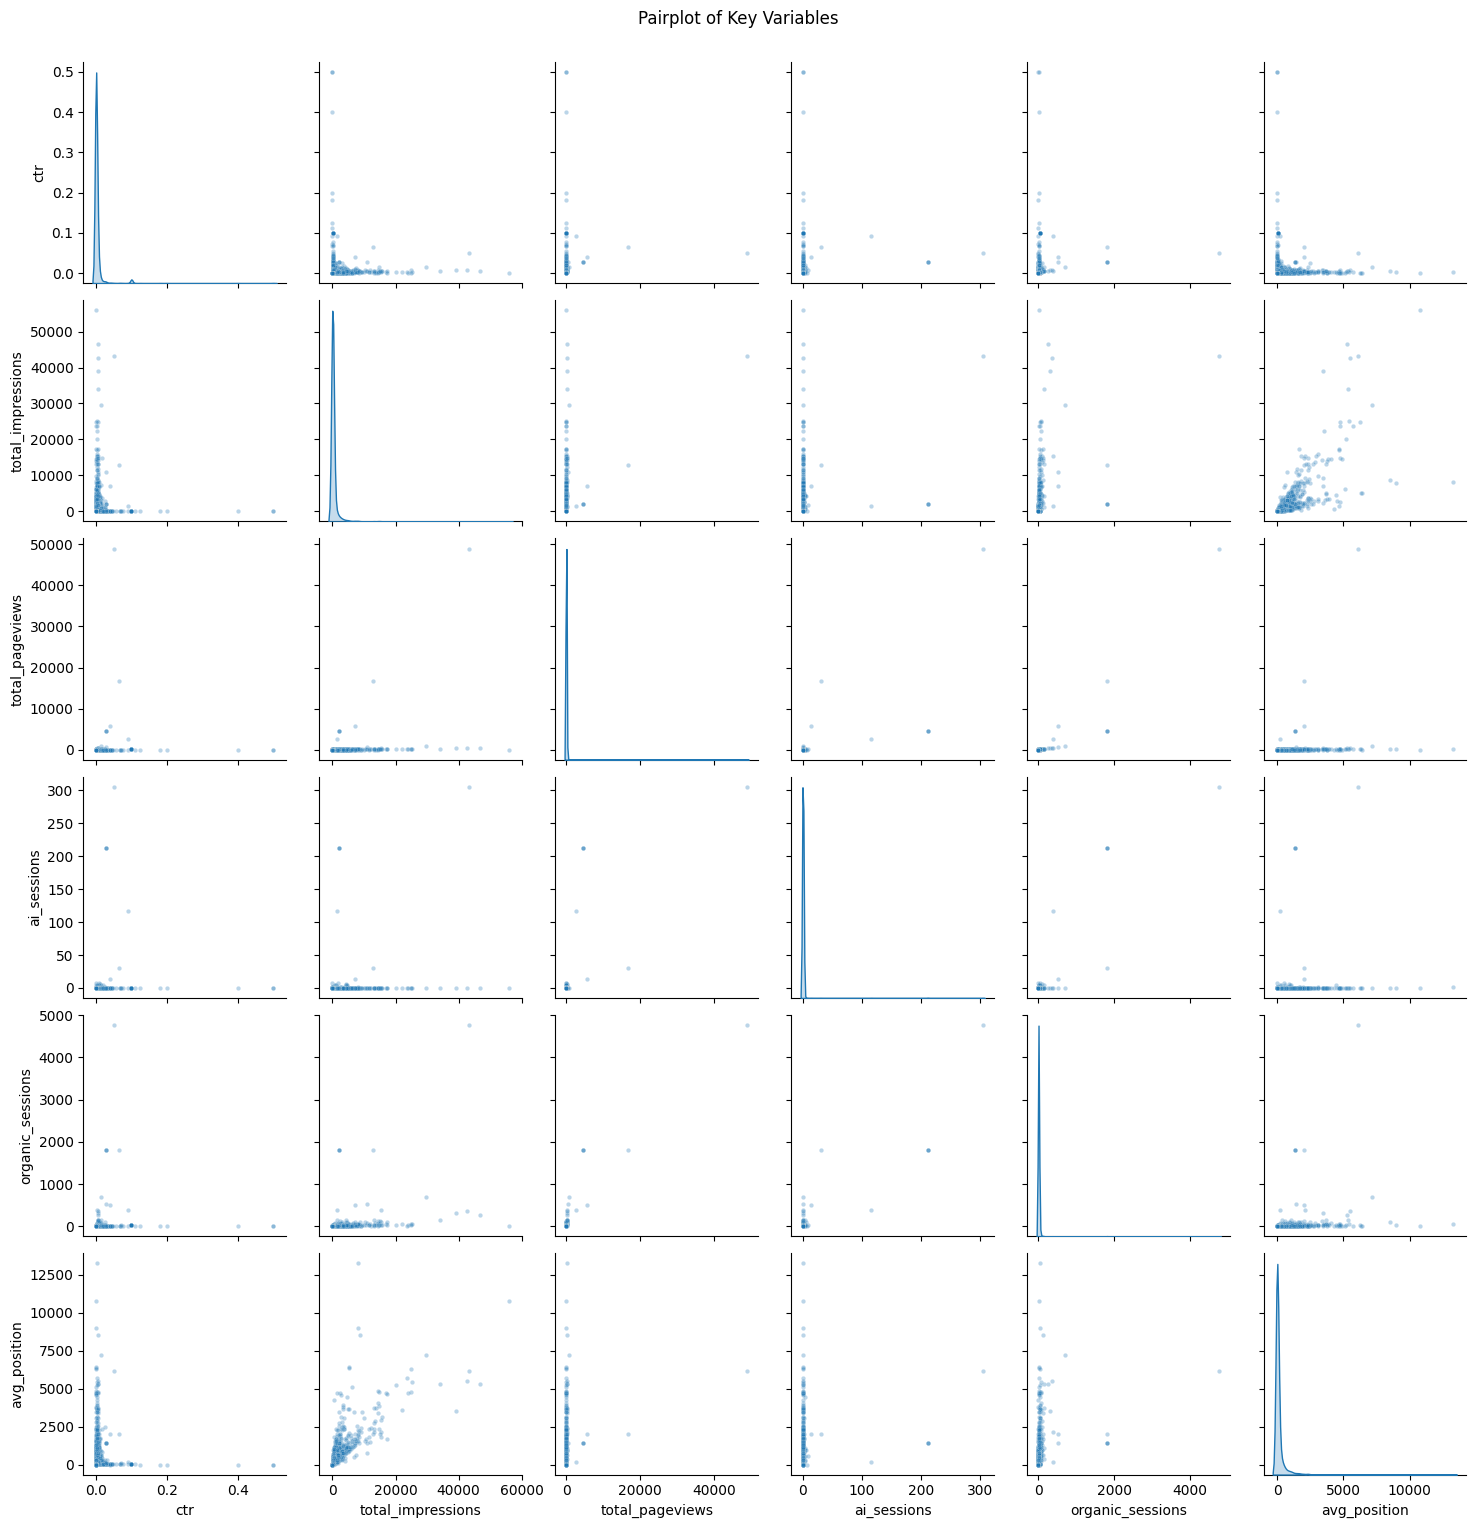

In [20]:
# ============================================================
# CELL 12: MULTIVARIATE - PAIRPLOT (SELECTED VARIABLES)
# ============================================================

print("\n" + "="*50)
print("MULTIVARIATE - PAIRPLOT (Selected Variables)")
print("="*50)

# Select key variables for pairplot
pairplot_vars = ['ctr', 'total_impressions', 'total_pageviews',
                 'ai_sessions', 'organic_sessions', 'avg_position']

existing_pairplot = [col for col in pairplot_vars if col in df.columns]

if len(existing_pairplot) >= 2:
    # Sample data for visualization (use 5000 rows for performance)
    sample_data = df[existing_pairplot].sample(n=min(5000, len(df)), random_state=42)

    # Create pairplot
    fig = plt.figure(figsize=(14, 12))
    g = sns.pairplot(sample_data, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
    g.fig.suptitle('Pairplot of Key Variables', y=1.02)

    plt.show()

The pairplot provides a grid of scatter plots for each pair of selected key variables (ctr, total_impressions, total_pageviews, ai_sessions, organic_sessions, avg_position) and histograms/KDEs for individual variable distributions. It visually confirms the distributions and bivariate relationships seen earlier, reinforcing that many relationships are non-linear or contain significant spread. The diagonal plots show the density distribution for each variable, often revealing high concentrations at lower values and long tails.


MULTIVARIATE - PERFORMANCE CLUSTERS (K-Means)


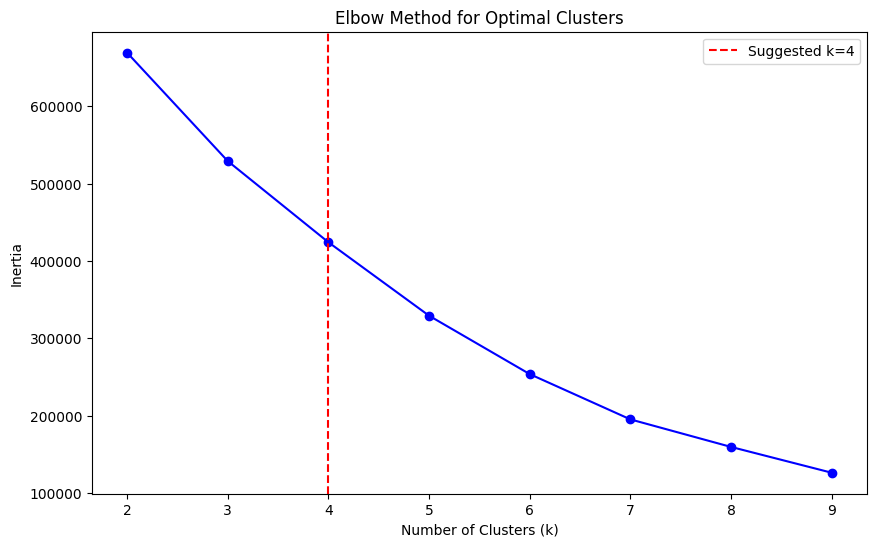


📊 Cluster Characteristics (Mean Values):
------------------------------------------------------------
              ctr  total_impressions  total_pageviews  ai_sessions  \
cluster                                                              
0        0.007375         986.314409        14.223417     0.031304   
1        0.535368      275286.500000    704238.000000   877.000000   
2        0.010174         345.469620         2.863291     0.011392   
3        0.030291        5470.264957      8298.085470   218.307692   

         organic_sessions  engagement_per_view  
cluster                                         
0                6.605591             1.990753  
1           103297.000000             0.019388  
2                1.907595           241.558891  
3             2044.521368             2.148141  


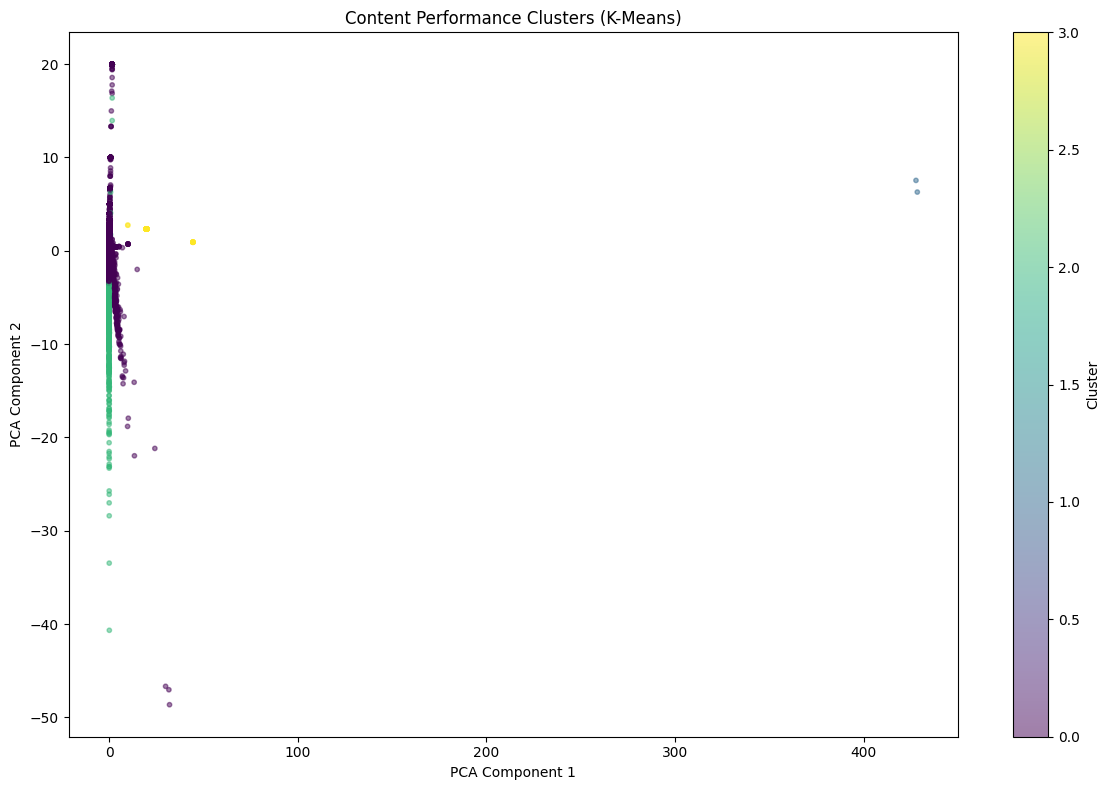

In [21]:
# ============================================================
# CELL 13: MULTIVARIATE - PERFORMANCE CLUSTERS (K-MEANS)
# ============================================================

print("\n" + "="*50)
print("MULTIVARIATE - PERFORMANCE CLUSTERS (K-Means)")
print("="*50)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select clustering variables
cluster_vars = ['ctr', 'total_impressions', 'total_pageviews',
                'ai_sessions', 'organic_sessions', 'engagement_per_view']

existing_cluster = [col for col in cluster_vars if col in df.columns]

# Prepare data
cluster_data = df[existing_cluster].copy()
cluster_data = cluster_data.fillna(0)
cluster_data = cluster_data.replace([np.inf, -np.inf], 0)

# Filter rows with some activity
cluster_data = cluster_data[(cluster_data > 0).any(axis=1)]

if len(cluster_data) >= 100:
    # Standardize
    scaler = StandardScaler()
    cluster_scaled = scaler.fit_transform(cluster_data)

    # Find optimal number of clusters (Elbow method)
    inertias = []
    k_range = range(2, 10)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(cluster_scaled)
        inertias.append(kmeans.inertia_)

    # Display elbow plot
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal Clusters')
    plt.axvline(x=4, color='r', linestyle='--', label='Suggested k=4')
    plt.legend()
    plt.show()

    # Apply K-means with 4 clusters
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_scaled)

    # Add cluster labels to data
    cluster_data['cluster'] = cluster_labels

    # Analyze clusters
    print("\n📊 Cluster Characteristics (Mean Values):")
    print("-"*60)
    cluster_summary = cluster_data.groupby('cluster')[existing_cluster].mean()
    print(cluster_summary)

    # Visualize clusters (first two components)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(cluster_scaled)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                         c=cluster_labels, cmap='viridis', alpha=0.5, s=10)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('Content Performance Clusters (K-Means)')
    plt.colorbar(scatter, label='Cluster')
    plt.tight_layout()
    plt.show()

- Elbow Method for Optimal Clusters Plot: The elbow plot suggests that 4 clusters (k=4) might be an optimal choice, as the inertia significantly decreases up to this point and then plateaus. This indicates a good balance between minimizing within-cluster sum-of-squares and keeping the number of clusters manageable.
- Content Performance Clusters (K-Means) Plot: The PCA scatter plot, colored by the identified K-Means clusters, visually demonstrates how content pieces group together based on their performance characteristics. Different clusters occupy distinct regions in the PCA space, indicating meaningful distinctions in content behavior.
- Cluster Characteristics (Mean Values): This table provides the mean values for the clustering variables within each of the 4 clusters:
  - Cluster 0: Represents content with moderate impressions and CTR, low pageviews and sessions, and moderate engagement per view. This could be a 'baseline' performance cluster.
 - Cluster 1: Characterized by extremely high impressions, pageviews, and AI sessions, along with a very high CTR (0.535). This is likely a 'high-performing' or 'viral' content cluster, possibly with single data point influencing due to max values being so high.
 - Cluster 2: Shows low impressions and sessions, but very high engagement_per_view (241.56s) and moderate CTR. This might represent highly engaging, niche content that attracts fewer overall sessions but captures user attention effectively.
 - Cluster 3: Features moderate to high impressions, pageviews, AI sessions, and organic sessions, with a decent CTR (0.030). This could be a 'well-performing' content cluster, with significant AI activity.


In [22]:
# ============================================================
# CELL 14: MULTIVARIATE - SUMMARY & KEY INSIGHTS
# ============================================================

print("\n" + "="*70)
print("EDA SUMMARY - KEY INSIGHTS")
print("="*70)

# Calculate key metrics
total_impressions = df['total_impressions'].sum()
total_clicks = df['total_clicks'].sum()
total_ai = df['ai_sessions'].sum()
total_organic = df['organic_sessions'].sum()
total_pageviews = df['total_pageviews'].sum()

# Correlation insights
corr_with_ctr = df[existing_numerical].corr()['ctr'].sort_values(ascending=False)

print("\n📊 1. UNIVARIATE INSIGHTS:")
print("-"*50)
print(f"  - Average CTR: {df[df['ctr']>0]['ctr'].mean():.4f}")
print(f"  - Average Position: {df[df['avg_position']>0]['avg_position'].mean():.2f}")
print(f"  - Average Engagement/View: {df[df['engagement_per_view']>0]['engagement_per_view'].mean():.2f}s")
print(f"  - Active Days (avg): {df['active_days'].mean():.1f} days")
print(f"  - Content with AI Traffic: {df['has_ai'].sum():,} ({df['has_ai'].sum()/len(df)*100:.1f}%)")

print("\n📊 2. BIVARIATE INSIGHTS (Top Correlations with CTR):")
print("-"*50)
for var, corr in corr_with_ctr.drop('ctr').head(5).items():
    print(f"  {var}: {corr:.3f}")

print("\n📊 3. MULTIVARIATE INSIGHTS:")
print("-"*50)
print(f"  - Total Impressions: {total_impressions:,.0f}")
print(f"  - Total Clicks: {total_clicks:,.0f}")
print(f"  - Overall CTR: {total_clicks/total_impressions*100:.2f}%")
print(f"  - Total Pageviews: {total_pageviews:,.0f}")
print(f"  - Total AI Sessions: {total_ai:,.0f} ({total_ai/(total_ai+total_organic)*100:.1f}% of traffic)")
print(f"  - Total Organic Sessions: {total_organic:,.0f}")

print("\n" + "="*70)
print("✅ EDA COMPLETE!")
print("="*70)
print("\n📋 Next Steps:")
print("  1. Ranking Signal Analysis (Notebook 4)")
print("  2. AI Referral Analysis (Notebook 5)")
print("  3. Opportunity Modeling (Notebook 6)")


EDA SUMMARY - KEY INSIGHTS

📊 1. UNIVARIATE INSIGHTS:
--------------------------------------------------
  - Average CTR: 0.0194
  - Average Position: 405.93
  - Average Engagement/View: 11.33s
  - Active Days (avg): 28.3 days
  - Content with AI Traffic: 2,177 (0.7%)

📊 2. BIVARIATE INSIGHTS (Top Correlations with CTR):
--------------------------------------------------
  organic_sessions: 0.064
  total_users: 0.059
  direct_sessions: 0.058
  total_scrolls: 0.057
  total_pageviews: 0.057

📊 3. MULTIVARIATE INSIGHTS:
--------------------------------------------------
  - Total Impressions: 173,401,788
  - Total Clicks: 1,011,034
  - Overall CTR: 0.58%
  - Total Pageviews: 4,861,097
  - Total AI Sessions: 32,762 (2.0% of traffic)
  - Total Organic Sessions: 1,598,823

✅ EDA COMPLETE!

📋 Next Steps:
  1. Ranking Signal Analysis (Notebook 4)
  2. AI Referral Analysis (Notebook 5)
  3. Opportunity Modeling (Notebook 6)


Overall, the EDA reveals significant skewness in many performance metrics, a strong inter-correlation among engagement and volume metrics, and distinct behavioral patterns for content, particularly those influenced by AI channels.